
COMPUERTA AND
Pesos iniciales (comunes para esta compuerta): 
[-0.11848792 -0.3797504  -0.09310416]
μ = 0.01 | Épocas: 36  | Pesos finales: [w0=0.169, w1=0.111, w2=0.175]
μ = 0.25 | Épocas: 150 | Pesos finales: [w0=0.250, w1=0.300, w2=0.350]
μ = 0.5  | Épocas: 150 | Pesos finales: [w0=0.250, w1=0.500, w2=0.750]
μ = 0.75 | Épocas: 150 | Pesos finales: [w0=5539368262702698355097631474057216.000, w1=41582455817755909571780957666541568.000, w2=82794299152964582560065376346963968.000]

COMPUERTA OR
Pesos iniciales (comunes para esta compuerta): 
[-0.15275435 -0.44322274 -0.2992753 ]
μ = 0.01 | Épocas: 47  | Pesos finales: [w0=0.622, w1=0.150, w2=0.168]
μ = 0.25 | Épocas: 150 | Pesos finales: [w0=0.750, w1=0.200, w2=0.150]
μ = 0.5  | Épocas: 150 | Pesos finales: [w0=0.750, w1=-0.000, w2=-0.250]
μ = 0.75 | Épocas: 150 | Pesos finales: [w0=-12103837525997847948069086745853952.000, w1=-90860052136077367878383206792167424.000, w2=-180910294730503205218394978841001984.000]

COMPUERTA NAND
Pesos 

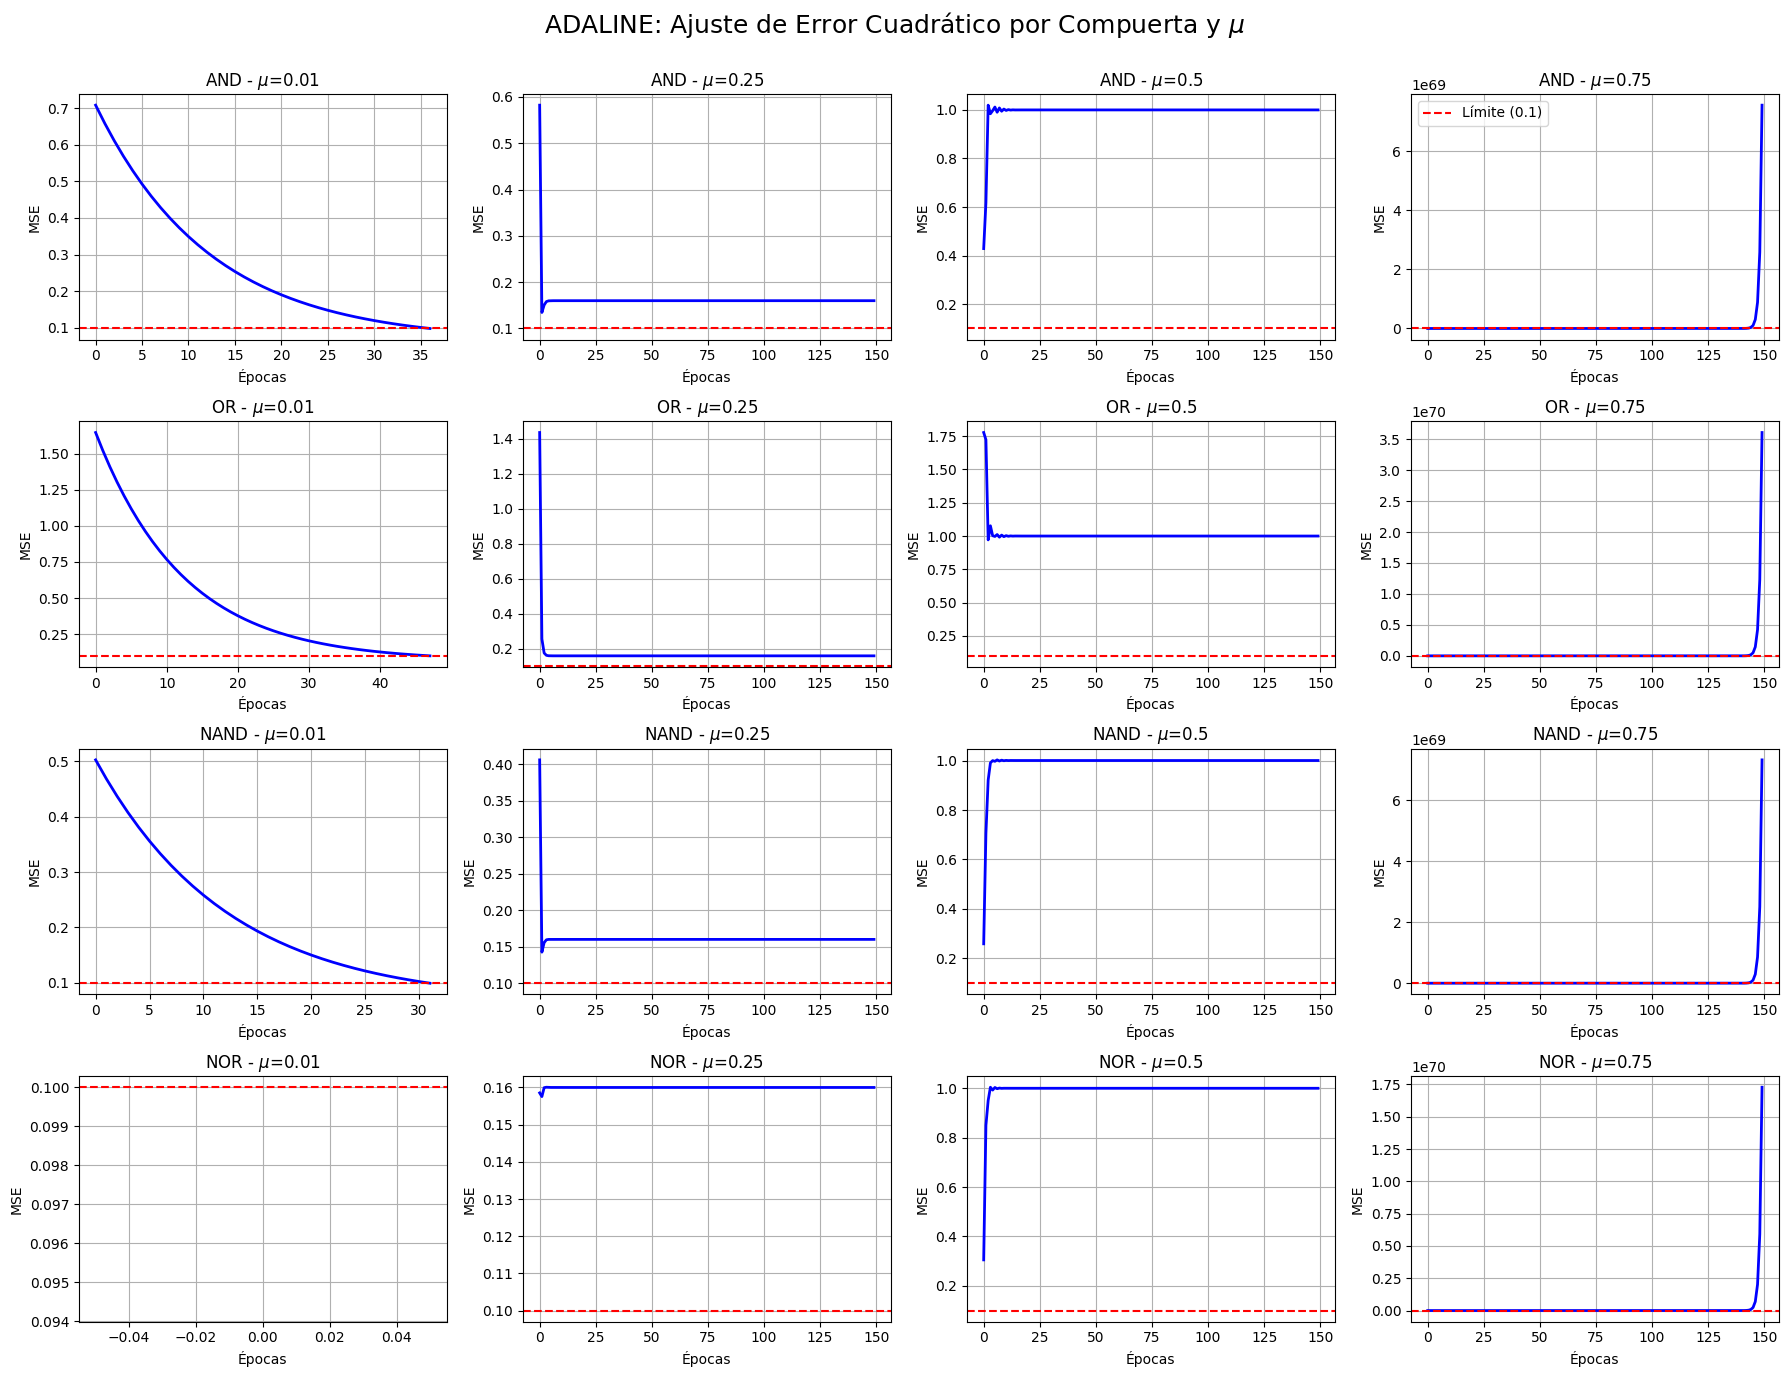

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Entradas bipolares
X = np.array([
    [-1, -1],
    [-1,  1],
    [ 1, -1],
    [ 1,  1]
])

# Salidas deseadas
targets = {
    'AND':  np.array([0 , 0 , 0 ,  1]),
    'OR':   np.array([0,  1,  1,  1]),
    'NAND': np.array([ 1,  1,  1, 0]),
    'NOR':  np.array([ 1, 0, 0, 0])
}

mus = [0.01, 0.25, 0.5, 0.75]
limite_error = 0.1
max_epocas = 150

# Crear una cuadrícula de 4x4 para las 16 gráficas
fig, axs = plt.subplots(4, 4, figsize=(18, 14))
fig.suptitle('ADALINE: Ajuste de Error Cuadrático por Compuerta y $\mu$', fontsize=18)

for i, (nombre_compuerta, T) in enumerate(targets.items()):
    
    # Pesos iniciales (w0 para sesgo, w1, w2)
    pesos_iniciales = np.random.uniform(-0.5, 0.5, 3)
    
    print(f"\n{'='*40}")
    print(f"COMPUERTA {nombre_compuerta}")
    print(f"Pesos iniciales (comunes para esta compuerta): \n{pesos_iniciales}")
    print(f"{'='*40}")
    
    for j, mu in enumerate(mus):
        w = pesos_iniciales.copy()
        historial_error = []
        epoca = 0
        
        while epoca < max_epocas:
            error_total = 0
            
            for k in range(len(X)):
                x_k = np.insert(X[k], 0, 1.0) # Insertar sesgo
                
                y_in = np.dot(w, x_k)
                error = T[k] - y_in
                error_total += error**2
                
                w += mu * error * x_k
                
            mse = error_total / len(X)
            historial_error.append(mse)
            
            if mse <= limite_error:
                break
                
            epoca += 1
            
        # Imprimir resultados en consola
        print(f"μ = {mu:<4} | Épocas: {epoca:<3} | Pesos finales: [w0={w[0]:.3f}, w1={w[1]:.3f}, w2={w[2]:.3f}]")
            
        # Seleccionar la subgráfica correspondiente (Fila i, Columna j)
        ax = axs[i, j]
        ax.plot(historial_error, color='blue', linewidth=2)
        ax.axhline(y=limite_error, color='red', linestyle='--', label='Límite (0.1)')
        
        ax.set_title(f'{nombre_compuerta} - $\mu$={mu}')
        ax.set_xlabel('Épocas')
        ax.set_ylabel('MSE')
        ax.grid(True)
        if i == 0 and j == 3: # Poner la leyenda solo en una para no saturar
            ax.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()